# 🏦 Loan Approval Classification — EDA & Model Comparison

Walkthrough of the dataset and modeling approach behind this repo. The reusable
implementation lives in the `loan_approval` package; this notebook covers
exploration and the model comparison narrative.

- **Dataset:** [Loan Approval Classification Dataset](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data) (Kaggle, taweilo) — 45,000 loan applications, synthetic credit-risk data.
- **Target:** `loan_status` — 1 = approved, 0 = rejected.
- **Original notebook:** [prishababel/loan-approval-classification](https://www.kaggle.com/code/prishababel/loan-approval-classification)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # make the loan_approval package importable

from loan_approval import config
from loan_approval.data import load_dataset, split_features_target

# Validated chart palette (see README)
BLUE, ORANGE, MUTED = "#2a78d6", "#eb6834", "#898781"

df = load_dataset()
print(f"{len(df):,} rows after cleaning")
df.head()

44,990 rows after cleaning


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 1. Exploratory data analysis

The dataset ships complete — no missing values, no duplicates. Cleaning only
drops a handful of implausible rows (age > 90, employment experience > 60
years).

In [2]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
person_age,44990.0,27.74,5.89,20.00,24.00,26.00,30.00,78.00
person_income,44990.0,79908.83,63323.59,8000.00,47195.75,67045.50,95777.00,2448661.00
person_emp_exp,44990.0,5.39,5.91,0.00,1.00,4.00,8.00,58.00
loan_amnt,44990.0,9583.30,6314.98,500.00,5000.00,8000.00,12237.75,35000.00
loan_int_rate,44990.0,11.01,2.98,5.42,8.59,11.01,12.99,20.00
loan_percent_income,44990.0,0.14,0.09,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,44990.0,5.87,3.87,2.00,3.00,4.00,8.00,30.00
credit_score,44990.0,632.58,50.39,390.00,601.00,640.00,670.00,784.00
loan_status,44990.0,0.22,0.42,0.00,0.00,0.00,0.00,1.00


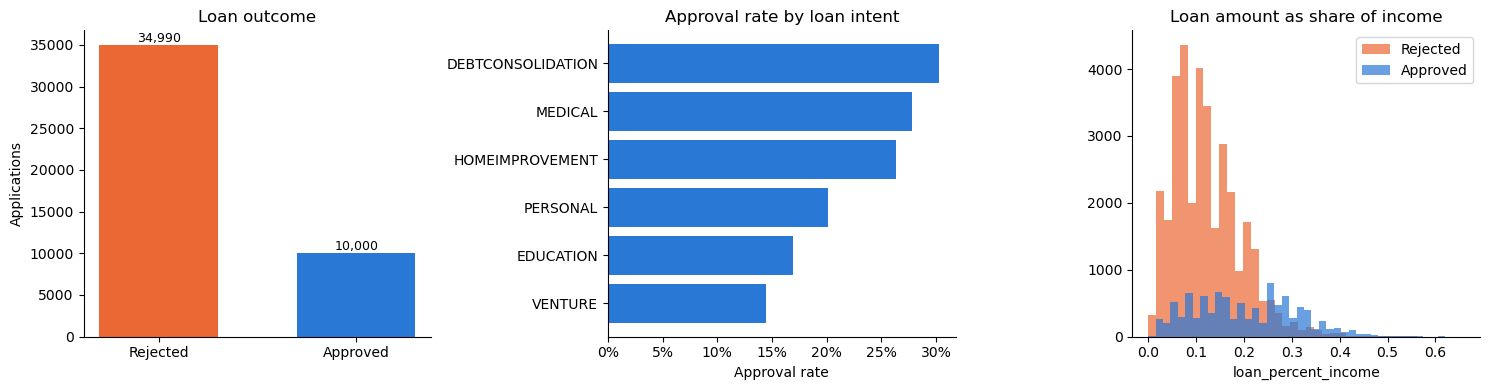

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance — two outcome series, fixed colors + labels
counts = df[config.TARGET].map(config.TARGET_LABELS).value_counts()
axes[0].bar(counts.index, counts.values, color=[ORANGE, BLUE], width=0.6)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Loan outcome")
axes[0].set_ylabel("Applications")

# Approval rate by loan intent — one measure, one hue
rate = df.groupby("loan_intent")[config.TARGET].mean().sort_values()
axes[1].barh(rate.index, rate.values, color=BLUE)
axes[1].set_title("Approval rate by loan intent")
axes[1].set_xlabel("Approval rate")
axes[1].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

# Loan-to-income ratio by outcome — two series, legend
for label, color in [("Rejected", ORANGE), ("Approved", BLUE)]:
    subset = df[df[config.TARGET].map(config.TARGET_LABELS) == label]
    axes[2].hist(subset["loan_percent_income"], bins=40, alpha=0.7, label=label, color=color)
axes[2].set_title("Loan amount as share of income")
axes[2].set_xlabel("loan_percent_income")
axes[2].legend()

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**What stands out**

- Only ~22% of applications are approved — the classes are imbalanced, so we
  track ROC-AUC and F1 rather than accuracy alone.
- Approval rates differ by intent, but the strongest signals are financial:
  loans that eat a large share of income are approved far more rarely.
- `previous_loan_defaults_on_file` is decisive: no applicant with a prior
  default on file is approved in this dataset.

In [4]:
pd.crosstab(df["previous_loan_defaults_on_file"], df[config.TARGET].map(config.TARGET_LABELS))

loan_status,Approved,Rejected
previous_loan_defaults_on_file,,
No,10000,12135
Yes,0,22855


## 2. Preprocessing & models

All models share one `sklearn` pipeline — `StandardScaler` on the eight numeric
features, `OneHotEncoder` on the five categoricals — so the comparison is
apples-to-apples and the winning pipeline can be serialized as a single
artifact. We compare Logistic Regression (linear baseline), Random Forest, and
Histogram Gradient Boosting on a stratified 20% hold-out set.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from loan_approval.evaluate import evaluate_model
from loan_approval.train import build_models, build_preprocessor

X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, stratify=y, random_state=config.RANDOM_STATE
)

results = {}
for name, model in build_models().items():
    pipeline = Pipeline([("preprocess", build_preprocessor()), ("model", model)])
    pipeline.fit(X_train, y_train)
    results[name] = evaluate_model(pipeline, X_test, y_test)

comparison = pd.DataFrame(results).T[["roc_auc", "accuracy", "precision", "recall", "f1"]]
comparison.sort_values("roc_auc", ascending=False).round(4)

,roc_auc,accuracy,precision,recall,f1
Hist Gradient Boosting,0.9771,0.932,0.8881,0.794,0.8384
Random Forest,0.9736,0.9275,0.9002,0.758,0.823
Logistic Regression,0.954,0.8976,0.782,0.748,0.7646


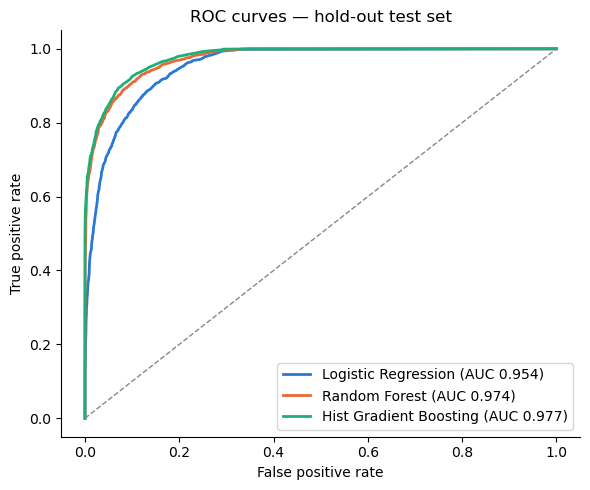

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"Logistic Regression": "#2a78d6", "Random Forest": "#eb6834", "Hist Gradient Boosting": "#1baf7a"}
for name, res in results.items():
    ax.plot(res["roc_curve"]["fpr"], res["roc_curve"]["tpr"],
            label=f"{name} (AUC {res['roc_auc']:.3f})", color=colors[name], linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color=MUTED, linewidth=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — hold-out test set")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Conclusion

Histogram Gradient Boosting wins (ROC-AUC ≈ 0.977) and is the model that
`python -m loan_approval.train` saves to `models/model.joblib`, which the
Streamlit app (`streamlit run streamlit_app.py`) serves for interactive
predictions.